# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import LabelEncoder
import urllib.request
from xgboost import XGBRegressor

## 2. Datos

In [2]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv", index_col= "laptop_ID")

### 2.1 Exploración de los datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   Product           912 non-null    object 
 2   TypeName          912 non-null    object 
 3   Inches            912 non-null    float64
 4   ScreenResolution  912 non-null    object 
 5   Cpu               912 non-null    object 
 6   Ram               912 non-null    object 
 7   Memory            912 non-null    object 
 8   Gpu               912 non-null    object 
 9   OpSys             912 non-null    object 
 10  Weight            912 non-null    object 
 11  Price_in_euros    912 non-null    float64
dtypes: float64(2), object(10)
memory usage: 92.6+ KB


In [4]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [5]:
df.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [6]:
df.describe()

,Inches,Price_in_euros
count,912.000000,912.000000
mean,14.981579,1111.724090
std,1.436719,687.959172
min,10.100000,174.000000
25%,14.000000,589.000000
50%,15.600000,978.000000
75%,15.600000,1483.942500
max,18.400000,6099.000000


In [7]:
for col in df.columns:
    print(f"Para {col} hay {df[col].nunique()} valores únicos")

Para Company hay 19 valores únicos
Para Product hay 480 valores únicos
Para TypeName hay 6 valores únicos
Para Inches hay 17 valores únicos
Para ScreenResolution hay 36 valores únicos
Para Cpu hay 107 valores únicos
Para Ram hay 9 valores únicos
Para Memory hay 37 valores únicos
Para Gpu hay 93 valores únicos
Para OpSys hay 9 valores únicos
Para Weight hay 165 valores únicos
Para Price_in_euros hay 603 valores únicos


In [8]:
for col in df.columns:
    print(f"Para \033[1m{col}\033[0m hay {df[col].unique()}\n")

Para Company hay ['HP' 'Dell' 'Apple' 'Lenovo' 'MSI' 'Toshiba' 'Acer' 'Chuwi' 'Asus'
 'Huawei' 'Razer' 'Mediacom' 'Google' 'Samsung' 'Xiaomi' 'Microsoft'
 'Vero' 'LG' 'Fujitsu']

Para Product hay ['250 G6' 'Inspiron 7559' 'ProBook 450' 'Macbook Air' 'Inspiron 3567'
 'ProBook 650' 'Envy 13-AD007nv' 'IdeaPad 320-15IKB' 'GL72M 7REX'
 'Thinkpad T570' 'MacBook Pro' 'Ideapad 320-15IKBR' 'IdeaPad 320-15IAP'
 'Portege Z30-C-16P' 'Latitude 5590' 'IdeaPad 110-15IBR' 'GP72MVR 7RFX'
 'ThinkPad X1' 'GL62 6QF' 'Portege X30-D-10X' 'Chromebook 11'
 'Inspiron 5567' 'IdeaPad 510s-14IKB' 'LapBook 15.6"' 'GE62 Apache'
 'ZBook 17' 'Inspiron 7567' 'VivoBook Pro' 'Pro P2540UA-XO0198T'
 'Thinkpad 13' 'MateBook X' 'Vostro 5568' '250 G5' 'EliteBook 840'
 'Inspiron 7570' 'IdeaPad Y700-15ISK' 'ThinkPad P51' 'IdeaPad 320-15IKBN'
 'Portege Z30-C-1CV' 'XPS 13' 'IdeaPad 510-15IKB'
 '15-bs002nv (i3-6006U/4GB/128GB/FHD/W10)' 'Blade Pro' 'Rog Strix'
 'ProBook 440' '15-AC110nv (i7-6500U/6GB/1TB/Radeon' 'Probook 440'
 'FX

Funciones para trnsformar categóricas en numéricas

In [9]:
import re

# Extrae memoria
def extrae_memoria(text):
    matches = re.findall(r'(\d+)\s*(GB|TB)', text)
    
    total_gb = 0
    
    for value, unit in matches:
        value = int(value)
        if unit == "TB":
            value *= 1024
        total_gb += value
    
    return total_gb

# Extrae CPU
def extrae_cpu(text):
    matches = re.findall(r'(\d+(?:\.\d+)?)\s*GHz', text)
    
    total_ghz = 0
    
    for value in matches:
        value = float(value)
        total_ghz += value
    
    return total_ghz
# Transforma memoria
def transforma_memoria(df,col_name):
    df["has_ssd"] = df[col_name].str.contains("SSD", case=False).astype(int)
    df["has_hdd"] = df[col_name].str.contains("HDD", case=False).astype(int)
    df["has_flash"] = df[col_name].str.contains("Flash", case=False).astype(int)
    df["has_hybrid"] = df[col_name].str.contains("Hybrid", case=False).astype(int)

    df["memory_gb"] = df[col_name].apply(extrae_memoria)
    return df

# Transforma resolucion
def parse_resolution(res):
    match = re.search(r'(\d+)x(\d+)', res)
    if match:
        w, h = map(int, match.groups())
        return w * h
    return None

# transforma OS
def categoriza_os(df):
    map_os = {
        'No OS' : 0,
        'Windows 7': 1,
        'Windows 10 S': 2,
        'Chrome OS': 3,
        'Android': 4,
        'Linux': 5,
        'Mac OS X': 6,
        'macOS': 7,
        'Windows 10': 8
    }
    df["OpSys_num"] = df["OpSys"].map(map_os)
    return df["OpSys_num"]

# Transforma Type
def categoriza_type(df):
    
    map_type = {
        'Netbook' : 0,
        'Notebook': 1,
        '2 in 1 Convertible': 2,
        'Ultrabook': 3,
        'Gaming': 4,
        'Workstation': 5
    }
    df["TypeName_num"] = df["TypeName"].map(map_type)
    return df["TypeName_num"]

    

In [10]:
def optimizar_df(df):

    df["ram_gb"] = df["Ram"].str.replace("GB", "").astype(int)
    df["weight_kg"] = df.Weight.str.replace("kg","").astype(float)
    df = transforma_memoria(df,"Memory")
    df["cpu_ghz"] = df["Cpu"].apply(extrae_cpu)
    df["resolution_pixels"] = df["ScreenResolution"].apply(parse_resolution)
    df["OpSys_num"] = categoriza_os(df)
    df["TypeName_num"] = categoriza_type(df)
    return df

In [11]:
df = optimizar_df(df)

In [12]:
df.head(15)

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,...,weight_kg,has_ssd,has_hdd,has_flash,has_hybrid,memory_gb,cpu_ghz,resolution_pixels,OpSys_num,TypeName_num
laptop_ID,,,,,,,,,,,,,,,,,,,,,
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,...,1.86,1,0,0,0,256,2.0,2073600,8,1
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,...,2.59,0,1,0,0,1024,2.6,2073600,8,4
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,...,2.04,0,1,0,0,1024,2.7,2073600,8,1
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,...,1.34,0,0,1,0,128,1.8,1296000,7,3
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,...,2.25,0,1,0,0,1024,2.0,2073600,5,1
627,HP,ProBook 650,Notebook,14.0,1366x768,Intel Core i5 7300U 2.6GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,...,2.31,1,0,0,0,256,2.6,1049088,8,1
142,HP,Envy 13-AD007nv,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,...,1.32,1,0,0,0,256,2.5,2073600,8,1
19,Lenovo,IdeaPad 320-15IKB,Notebook,15.6,Full HD 1920x1080,Intel Core i3 7100U 2.4GHz,8GB,1TB HDD,Nvidia GeForce 940MX,No OS,...,2.20,0,1,0,0,1024,2.4,2073600,0,1
732,MSI,GL72M 7REX,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050 Ti,Windows 10,...,2.70,1,1,0,0,1152,2.8,2073600,8,4


In [13]:
df.isna().sum()

Company              0
Product              0
TypeName             0
Inches               0
ScreenResolution     0
Cpu                  0
Ram                  0
Memory               0
Gpu                  0
OpSys                0
Weight               0
Price_in_euros       0
ram_gb               0
weight_kg            0
has_ssd              0
has_hdd              0
has_flash            0
has_hybrid           0
memory_gb            0
cpu_ghz              0
resolution_pixels    0
OpSys_num            0
TypeName_num         0
dtype: int64

In [14]:
corr_matrix = df.corr(numeric_only=True)

corr_with_target = corr_matrix["Price_in_euros"].sort_values(ascending=False)
print(corr_with_target)

Price_in_euros       1.000000
ram_gb               0.738922
TypeName_num         0.622791
has_ssd              0.516708
resolution_pixels    0.493671
cpu_ghz              0.427116
weight_kg            0.197086
memory_gb            0.191000
OpSys_num            0.137638
Inches               0.071043
has_hybrid          -0.036007
has_hdd             -0.150849
has_flash           -0.230861
Name: Price_in_euros, dtype: float64


In [15]:
best_num_features = corr_with_target[abs(corr_with_target) > 0.3].index.tolist()
best_num_features.remove("Price_in_euros")
print(best_num_features)


['ram_gb', 'TypeName_num', 'has_ssd', 'resolution_pixels', 'cpu_ghz']


### 2.3 Definir X e y

In [16]:
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 22)

In [17]:
y.shape

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [19]:
X_train

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,...,weight_kg,has_ssd,has_hdd,has_flash,has_hybrid,memory_gb,cpu_ghz,resolution_pixels,OpSys_num,TypeName_num
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,...,3.00,0,1,0,0,1024,2.6,2073600,1,5
153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,...,2.56,1,0,0,0,512,2.8,2073600,8,4
275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,...,1.37,1,0,0,0,512,2.9,4096000,7,3
1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,...,1.54,0,1,0,0,500,2.3,2073600,1,1
131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,...,2.80,1,1,0,0,2304,1.8,2073600,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,8GB,2TB HDD,Intel HD Graphics 405,Windows 10,...,1.94,0,1,0,0,2048,1.6,1049088,8,1
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,6GB,256GB SSD,AMD Radeon 530,Windows 10,...,2.20,1,0,0,0,256,3.6,2073600,8,1
770,Dell,Latitude 7280,Ultrabook,12.5,Full HD 1920x1080,Intel Core i7 7600U 2.8GHz,16GB,256GB SSD,Intel HD Graphics 620,Windows 10,...,1.18,1,0,0,0,256,2.8,2073600,8,3


In [20]:
y_train

laptop_ID
1118    2899.00
153     1249.26
275     1958.90
1100    1030.99
131     1396.00
         ...   
578      389.00
996      549.00
770     1859.00
407      306.00
418     1943.00
Name: Price_in_euros, Length: 729, dtype: float64

## 3. Procesado de datos

Nuestro target es la columna `Price_euros`

In [21]:
target = "Price_in_euros"

In [22]:
# No necesario, ya optimizado y transformado el df
# X_train = optimizar_df(X_train)

In [22]:
X_train

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,...,weight_kg,has_ssd,has_hdd,has_flash,has_hybrid,memory_gb,cpu_ghz,resolution_pixels,OpSys_num,TypeName_num
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,...,3.00,0,1,0,0,1024,2.6,2073600,1,5
153,Dell,Inspiron 5577,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,...,2.56,1,0,0,0,512,2.8,2073600,8,4
275,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,...,1.37,1,0,0,0,512,2.9,4096000,7,3
1100,HP,EliteBook 840,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,...,1.54,0,1,0,0,500,2.3,2073600,1,1
131,Dell,Inspiron 5770,Notebook,17.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,...,2.80,1,1,0,0,2304,1.8,2073600,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,8GB,2TB HDD,Intel HD Graphics 405,Windows 10,...,1.94,0,1,0,0,2048,1.6,1049088,8,1
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,Full HD 1920x1080,AMD A12-Series 9720P 3.6GHz,6GB,256GB SSD,AMD Radeon 530,Windows 10,...,2.20,1,0,0,0,256,3.6,2073600,8,1
770,Dell,Latitude 7280,Ultrabook,12.5,Full HD 1920x1080,Intel Core i7 7600U 2.8GHz,16GB,256GB SSD,Intel HD Graphics 620,Windows 10,...,1.18,1,0,0,0,256,2.8,2073600,8,3


In [24]:
# No necesario, ya optimizado y transformado el df
# X_test = optimizar_df(X_test)

In [23]:
X_test

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,...,weight_kg,has_ssd,has_hdd,has_flash,has_hybrid,memory_gb,cpu_ghz,resolution_pixels,OpSys_num,TypeName_num
laptop_ID,,,,,,,,,,,,,,,,,,,,,
451,HP,Omen 15-AX205na,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,...,2.20,1,1,0,0,1152,2.8,2073600,8,4
802,Lenovo,Yoga 510-15IKB,2 in 1 Convertible,15.6,Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,AMD Radeon R7 M460,Windows 10,...,2.08,1,0,0,0,256,2.5,2073600,8,2
723,Lenovo,Thinkpad E470,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Nvidia GeForce 920MX,Windows 10,...,1.87,1,0,0,0,256,2.5,2073600,8,1
682,HP,Pavilion X360,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i3 7100U 2.4GHz,4GB,128GB SSD,Nvidia GeForce 940MX,Windows 10,...,1.63,1,0,0,0,128,2.4,2073600,8,2
1306,Asus,X553SA-XX031T (N3050/4GB/500GB/W10),Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,...,2.20,0,1,0,0,500,1.6,1049088,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,1TB HDD,Intel HD Graphics 620,Windows 10,...,1.86,0,1,0,0,1024,2.5,2073600,8,1
626,Acer,CB5-132T-C9KK (N3160/4GB/32GB/Chrome,2 in 1 Convertible,11.6,IPS Panel Touchscreen 1366x768,Intel Celeron Quad Core N3160 1.6GHz,4GB,32GB Flash Storage,Intel HD Graphics 400,Chrome OS,...,1.25,0,0,1,0,32,1.6,1049088,3,2
416,Lenovo,Lenovo IdeaPad,Notebook,11.6,1366x768,Intel Celeron Dual Core N3350 1.1GHz,2GB,32GB Flash Storage,Intel HD Graphics 500,Windows 10,...,1.15,0,0,1,0,32,1.1,1049088,8,1


In [24]:
features_num = ["Inches", "ram_gb", "weight_kg","memory_gb","has_ssd","has_hdd","has_flash","has_hybrid","resolution_pixels","OpSys_num","TypeName_num","cpu_ghz"]

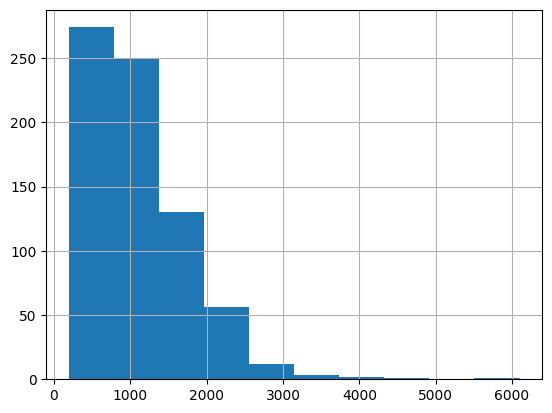

In [25]:
y_train.hist();

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [26]:
features_opt = int(input("¿Que features quieres:"))
if features_opt == 1:
    print("Has escogido todas las numéricas")
    X_train = X_train[features_num]
    X_test = X_test[features_num]
else: 
    print("Has escogido las 'mejores' numéricas")
    X_train = X_train[best_num_features]
    X_test = X_test[best_num_features]


Has escogido todas las numéricas


In [27]:
randomF = RandomForestRegressor(max_depth= 6, random_state= 42)
xgb = XGBRegressor(
    n_estimators=500,       
    max_depth=6,            
    learning_rate=0.05,     
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42
)

In [28]:
eleccion = input("¿Qué modelo quieres usar? (RF para RandomForest o XGB para XGBoost)")
if eleccion in ["RF","rf","Rf"]:
    print("Has elegido RandomForest:", eleccion)
    modelo = randomF
else:
    print("Has elegido XGBoost:", eleccion)
    modelo = xgb

Has elegido XGBoost: xgb


In [29]:
modelo.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.
Se pide que sea menor que 400

In [30]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (729, 12)
X_test: (183, 12)
y_train: (729,)
y_test: (183,)


In [31]:
y_pred = modelo.predict(X_train)

In [32]:
y_pred_test = modelo.predict(X_test)

In [33]:
from sklearn.metrics import root_mean_squared_error

RMSE_train = root_mean_squared_error(y_train,y_pred)
print("RMSE en train",RMSE_train)
RMSE_test = root_mean_squared_error(y_test,y_pred_test)
print("RMSE en test",RMSE_test)

RMSE en train 80.56181394860674
RMSE en test 332.56831301137254


### 4.3 Optimización (up to you 🫰🏻)

In [37]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100,200,1000],
    "max_depth": [1,5,10,20],
    "learning_rate": [0.1,0.3,0.6,1,0.01],
}


xgb_grid = RandomizedSearchCV(
    xgb,
    param_distributions= param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

xgb_grid.fit(X_train, y_train)

print(xgb_grid.best_params_)
print("Best RMSE CV:", xgb_grid.best_score_)



{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Best RMSE CV: -300.90171957500036


In [38]:
xgb_grid.best_estimator_

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [39]:
xgb_grid.best_params_

{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}

In [40]:
xgb_grid.best_score_

np.float64(-300.90171957500036)

In [42]:
y_pred_grid = xgb_grid.best_estimator_.predict(X_test)
RMSE_train_grid = root_mean_squared_error(y_train,y_pred)
print("RMSE modelo optimizado en train",RMSE_train)
RMSE_testgrid = root_mean_squared_error(y_test,y_pred_grid)
print("RMSE modelo optimizado en test",RMSE_test)

RMSE modelo optimizado en train 80.56181394860674
RMSE modelo optimizado en test 332.56831301137254


-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [43]:
X_pred = pd.read_csv("./data/test.csv",index_col= "laptop_ID")
X_pred.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


In [44]:
X_pred.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg
421,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg


In [45]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 209 to 421
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           391 non-null    object 
 1   Product           391 non-null    object 
 2   TypeName          391 non-null    object 
 3   Inches            391 non-null    float64
 4   ScreenResolution  391 non-null    object 
 5   Cpu               391 non-null    object 
 6   Ram               391 non-null    object 
 7   Memory            391 non-null    object 
 8   Gpu               391 non-null    object 
 9   OpSys             391 non-null    object 
 10  Weight            391 non-null    object 
dtypes: float64(1), object(10)
memory usage: 36.7+ KB


In [46]:
X_pred.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu',
       'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight'],
      dtype='object')

In [47]:
X_pred

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg
...,...,...,...,...,...,...,...,...,...,...,...
820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg


 ## 2. Replicar el procesado para ``test.csv``

In [48]:
X_pred = optimizar_df(X_pred)

In [49]:
X_pred

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,...,weight_kg,has_ssd,has_hdd,has_flash,has_hybrid,memory_gb,cpu_ghz,resolution_pixels,OpSys_num,TypeName_num
laptop_ID,,,,,,,,,,,,,,,,,,,,,
209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,...,2.400,1,0,0,0,512,2.8,2073600,0,4
1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,...,2.400,0,1,0,0,500,1.6,1049088,5,1
1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,...,1.900,0,1,0,0,1024,2.0,1049088,0,1
1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,...,2.191,1,0,0,0,256,2.5,2073600,8,2
1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,...,1.950,1,0,0,0,256,2.5,2073600,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,...,2.900,1,1,0,0,1536,2.8,2073600,8,4
948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,...,1.470,1,0,0,0,128,2.3,2073600,8,1
483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,...,1.780,1,0,0,0,256,2.8,2073600,8,5


In [43]:
if features_opt == 1:
    predictions_submit = modelo.predict(X_pred[features_num])
predictions_submit

array([1352.2917 ,  291.0777 ,  390.56747, 1055.0737 ,  895.5037 ,
        594.6932 ,  760.80273,  981.54297, 1304.9951 ,  288.1903 ,
       2563.7666 , 1425.3363 ,  537.11993, 1507.9832 , 1002.2184 ,
        597.19696, 2118.2678 , 1364.511  , 1783.1785 ,  640.6114 ,
       1279.2772 ,  259.03836,  609.2191 , 1600.5763 ,  472.9577 ,
        705.4975 ,  527.7624 , 1028.4941 , 2418.2178 , 1032.1976 ,
       1554.3479 ,  409.91   ,  863.9121 , 2856.6306 , 1998.483  ,
       2006.5366 ,  701.66437, 1281.1952 ,  886.29065, 1593.0668 ,
        504.38318,  753.5962 ,  552.3878 , 1157.522  , 1180.3767 ,
       1128.852  , 1015.40784,  526.1338 ,  648.72687,  412.62512,
       2029.2255 ,  744.63336, 1188.5427 ,  315.37292, 1820.6526 ,
       1572.8721 ,  646.4992 ,  909.96   ,  925.731  ,  687.76825,
       2962.6887 , 2441.1094 ,  485.69492, 2100.9863 , 1265.2937 ,
       1138.8528 ,  822.5918 , 1249.5664 , 1724.7706 , 2187.82   ,
        896.0522 ,  711.0706 ,  966.1192 , 1745.2162 ,  983.09

In [50]:
# Modelo optimizado
if features_opt == 1:
    predictions_submit = xgb_grid.predict(X_pred[features_num])
predictions_submit

array([1578.4646 ,  302.63675,  387.69263, 1027.0687 , 1007.30756,
        642.70996,  829.3652 ,  979.84064, 1309.9844 ,  316.50876,
       2560.564  , 1399.5105 ,  545.51733, 1713.4452 ,  955.3526 ,
        606.4088 , 2365.0942 , 1356.4639 , 1977.0161 ,  694.0178 ,
       1310.2063 ,  274.77148,  679.735  , 1559.0518 ,  519.7498 ,
        717.87494,  558.8678 , 1107.4607 , 2410.1868 , 1038.3636 ,
       1659.2021 ,  408.47934,  855.0045 , 2853.4592 , 2024.3583 ,
       2006.3606 ,  632.36633, 1230.2809 ,  923.7744 , 1599.3943 ,
        511.23718,  781.8701 ,  531.14703, 1222.4733 , 1184.7831 ,
       1126.8123 ,  988.4473 ,  531.1698 ,  667.0848 ,  440.8865 ,
       2223.5247 ,  726.0507 , 1178.4851 ,  352.3462 , 1824.7545 ,
       1647.336  ,  640.748  ,  869.7994 ,  939.45605,  672.85614,
       3083.3271 , 2240.8245 ,  469.38574, 2070.7356 , 1196.5885 ,
       1232.1871 ,  901.6261 , 1296.9852 , 1823.5747 , 2082.0364 ,
        879.20953,  706.83905, 1068.76   , 1678.1188 , 1002.60

In [51]:
predictions_submit.shape

(391,)

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [ ]:
# ¿Qué opináis?
# ¿Sí, no?

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [52]:
sample = pd.read_csv("data/sample_submission.csv")

In [46]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [46]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [53]:
#¿Cómo creamos la submission?
submission = pd.DataFrame({"laptop_ID": X_pred.index, "Price_in_euros": predictions_submit})

In [48]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1352.291748
1,1281,291.077698
2,1168,390.567474
3,1231,1055.073730
4,1020,895.503723


In [49]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [54]:
def chequeador(df_to_submit, times):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv(f"submission{eleccion.upper()}_v{times}.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [55]:
times = 3

In [56]:
times += 1
chequeador(submission,times)

You're ready to submit!
